# IDEN Model API

## Setup

```sh
# Pull the current model

# for our setup: rsync -r . maincompute:~/txregapi
# ssh maincompute "cd ~/txregapi; sudo docker-compose build; sudo docker-compose up -d"
export COMPOSE_PARALLEL_LIMIT=1
docker-compose build
docker-compose up -d

# You can also start the dev version of the api within the devcontainer:
# this should run in the background, but might have crashed
export MODEL_DIR=$(realpath ./model)
fastapi dev /workspace/src/api.py --host 0.0.0.0
```

Running the model (explaining) requires around 12 GB of RAM at the moment.

Now the following services are available:

- [Queue Dashboard](http://localhost:9181/) `queue_dashboard`
- [API and Doc](http://localhost:8000/docs#/) `mapi`
- Worker (used for predictions) `rqworker`
- Redis Server `redis`
- Devcontainer `devcontainer`

## Usage

### Data and Metadata


In [29]:

import requests
import pandas as pd
from IPython.display import Markdown, display
import time
import os


baseurl = os.getenv('API_BASEURL', 'http://localhost:8000')
baseurl = "http://localhost:8000/"

if not baseurl.endswith('/'):
    baseurl += '/'

s = requests.Session()

def error_hook(r, *args, **kwargs):
    if r.status_code != 200:
        print(f"Error: {r.status_code} - {r.text}")
    r.raise_for_status()

s.hooks = {
    'response': error_hook
}

A quick health check.

In [30]:
s.get(baseurl + "health").json()

{'status': 'ok'}

A model always gives survival predictions for specific time horizons. These are given in days.  

In [31]:
times = s.get(baseurl + "time_grid").json()
pd.Series(times).describe()

count     256.000000
mean      546.357422
std       317.294529
min         0.000000
25%       273.178711
50%       546.357422
75%       819.536133
max      1092.714844
dtype: float64

The model takes the following inputs.

There are numeric variables (have min, max), categorical variables (`multiple==False`), and multi-nominal variables (`multiple==TRUE`, seperated by ";;").
If the feature can be missing `NA`, `allowmissing` is `TRUE`.

These depend on the model and **will** change during development.

In [32]:
allowed_inputs = s.get(baseurl + "allowed_inputs").json()
display(Markdown(f"There are {len(allowed_inputs)} allowed inputs."))
allowed_inputs[:2]

There are 30 allowed inputs.

[{'variable': 'recipient_age',
  'dtype': 'float64',
  'allowmissing': False,
  'min': 16.118306115350883,
  'max': 85.94112816193324,
  'vals': None,
  'multiple': None},
 {'variable': 'donor_brain_damage_location',
  'dtype': 'object',
  'allowmissing': False,
  'min': None,
  'max': None,
  'vals': ['supratentoriell', 'unknown', 'gesamtcerebral', 'infratentoriell'],
  'multiple': False}]

In [33]:
allowed_inputs_df = pd.DataFrame.from_records(allowed_inputs)

numerics = allowed_inputs_df.query("min.notna()").dropna(how='all', axis=1)
display(Markdown("#### Numeric Inputs"))
display(numerics)

categorical = allowed_inputs_df.query("min.isna() & multiple == False").dropna(how='all', axis=1)
display(Markdown("#### Categorical Inputs"))
display(categorical)

multinomial = allowed_inputs_df.query("multiple == True").dropna(how='all', axis=1)
display(Markdown("#### Multinomial Inputs"))
display(multinomial)

#### Numeric Inputs

,variable,dtype,allowmissing,min,max
0,recipient_age,float64,False,16.118306,85.941128
2,recipient_total_number_of_changes_on_waitlist,float64,False,1.273402,24.999988
5,waiting_list_dialysis_years,float64,True,0.738738,29.013005
12,donor_chem_gamma_glutamyltransferase_u_per_l,float64,True,4.000000,2954.471210
13,donor_chem_international_normalized_ratio,float64,True,0.819684,34.461138
14,donor_age,float64,True,0.000034,89.032111
16,donor_height_cm,float64,True,135.000002,196.000001
19,donor_death_diagnosis_end_days,float64,True,-0.017385,4.214348
21,donor_chem_urea_mmol_per_l,float64,True,1.000000,78.709646
22,donor_chem_creatinine_umol_per_l,float64,True,17.807849,296.518049


#### Categorical Inputs

,variable,dtype,allowmissing,vals,multiple
1,donor_brain_damage_location,object,False,"[supratentoriell, unknown, gesamtcerebral, inf...",False
3,waiting_list_kidney_base_disease_icd10,object,True,"[Other, Q61.2, I12.0, N03.3, N03.9, E10.2, N18...",False
4,transplantation_destination,object,True,"[Regional, Home country, Abroad]",False
6,recipient_hepatitis_c_antibodies,object,True,"[negative, not tested, positive]",False
7,transplantation_assignment_type,object,True,"[Regular, Rescue]",False
8,organ_removal_perfusion_quality,object,True,"[good, acceptable]",False
9,donor_exam_worst_result,object,True,"[auffällig, pathologisch, unauffällig, grenzwe...",False
10,organ_removal_organ_quality,object,True,"[good, acceptable, poor]",False
11,donor_crossmatch_t_cell_match,object,True,"[negative, positive]",False
15,transplantation_dialysis,object,True,"[no, yes]",False


#### Multinomial Inputs

""


Example data for testing can be provided by the API:

In [34]:
example_data = s.get(baseurl + "input_example").json()
# It always has a single row
ex = example_data[0]
ex

{'waiting_list_kidney_base_disease_icd10': 'I12.0',
 'recipient_age': 69,
 'transplantation_destination': None,
 'waiting_list_dialysis_years': 3,
 'recipient_hepatitis_c_antibodies': None,
 'donor_brain_damage_location': 'infratentoriell',
 'transplantation_assignment_type': 'Regular',
 'recipient_total_number_of_changes_on_waitlist': 3,
 'organ_removal_perfusion_quality': 'good',
 'donor_exam_worst_result': 'auffällig',
 'organ_removal_organ_quality': None,
 'donor_crossmatch_t_cell_match': 'negative',
 'donor_chem_gamma_glutamyltransferase_u_per_l': 68,
 'donor_chem_international_normalized_ratio': 0.994404343451982,
 'donor_age': None,
 'transplantation_dialysis': 'no',
 'donor_height_cm': 176,
 'donor_death_reason_icd10': 'I60.9',
 'donor_urine_leukocytes_in_urine': '(+)',
 'donor_death_diagnosis_end_days': 1,
 'donor_virus_syphilis': None,
 'donor_chem_urea_mmol_per_l': 7,
 'donor_chem_creatinine_umol_per_l': 52,
 'donor_ambulant_treatment': 'no evidence',
 'donor_chem_hematocrit

In [35]:
# the example data has no missing values, lets make some missing
to_mask = allowed_inputs_df.query("allowmissing == True")["variable"].sample(frac=0.5, random_state=42)
for var in to_mask:
    ex[var] = None


In [36]:
ex

{'waiting_list_kidney_base_disease_icd10': None,
 'recipient_age': 69,
 'transplantation_destination': None,
 'waiting_list_dialysis_years': None,
 'recipient_hepatitis_c_antibodies': None,
 'donor_brain_damage_location': 'infratentoriell',
 'transplantation_assignment_type': None,
 'recipient_total_number_of_changes_on_waitlist': 3,
 'organ_removal_perfusion_quality': None,
 'donor_exam_worst_result': 'auffällig',
 'organ_removal_organ_quality': None,
 'donor_crossmatch_t_cell_match': None,
 'donor_chem_gamma_glutamyltransferase_u_per_l': None,
 'donor_chem_international_normalized_ratio': 0.994404343451982,
 'donor_age': None,
 'transplantation_dialysis': None,
 'donor_height_cm': None,
 'donor_death_reason_icd10': 'I60.9',
 'donor_urine_leukocytes_in_urine': '(+)',
 'donor_death_diagnosis_end_days': None,
 'donor_virus_syphilis': None,
 'donor_chem_urea_mmol_per_l': 7,
 'donor_chem_creatinine_umol_per_l': 52,
 'donor_ambulant_treatment': 'no evidence',
 'donor_chem_hematocrit_percen

## Doing Prediction

As the tasks may take a long time, a job queue system is employed.

In [37]:
pred_job = s.post(baseurl + "predict_survival_table", json=[ex]).json()

The `estimated_time` estimates the time between `started_at` and `finished_at` in seconds. The workers use caching, so subsequent calls with the same data will be faster (at the moment the estimate does not consider this fact).

In [38]:
pred_job

{'job_id': '28a9bcbf-e0a2-4b32-afba-aea1d2b6fcbc',
 'status': 'queued',
 'started_at': None,
 'enqueued_at': '2026-08-11T09:39:54.902624Z',
 'finished_at': None,
 'estimated_time': 0.044615,
 'job_type': 'predict_survival_table'}

Current status of the job can be checked.

In [39]:
# the example model is really fast, so we can just wait for the result
time.sleep(5)
s.get(baseurl + "job/" + pred_job["job_id"]).json()

{'job_id': '28a9bcbf-e0a2-4b32-afba-aea1d2b6fcbc',
 'status': 'finished',
 'started_at': '2026-08-11T09:39:54.938635Z',
 'enqueued_at': '2026-08-11T09:39:54.902624Z',
 'finished_at': '2026-08-11T09:39:54.959085Z',
 'estimated_time': 0.0325325,
 'job_type': 'predict_survival_table'}

We can get the results of the prediction job by its ID.

In [40]:
res = s.get(baseurl + "job/" + pred_job["job_id"] + "/result").json()
res

[{'observation': 0,
  't0': 0.9951857259944296,
  't1': 0.9856092319462116,
  't2': 0.9806403772578198,
  't3': 0.9766908261516194,
  't4': 0.9717892554052237,
  't5': 0.9683382711565279,
  't6': 0.965927179294981,
  't7': 0.9634039973103645,
  't8': 0.9599252071233143,
  't9': 0.9585520821107247,
  't10': 0.9559027716971885,
  't11': 0.9537780283426418,
  't12': 0.9520765192512478,
  't13': 0.9498419978270733,
  't14': 0.9472836038088124,
  't15': 0.9451448089537121,
  't16': 0.9439664901767525,
  't17': 0.9428935951346186,
  't18': 0.9410678469091781,
  't19': 0.9398849516255428,
  't20': 0.9382698694188206,
  't21': 0.9368677693446694,
  't22': 0.9351394513095641,
  't23': 0.9335160935901917,
  't24': 0.9325413638243135,
  't25': 0.9313491938545265,
  't26': 0.9303724268128266,
  't27': 0.9288509890283043,
  't28': 0.9270009167912254,
  't29': 0.9256930180982811,
  't30': 0.9246025862167377,
  't31': 0.9230740531416786,
  't32': 0.9216525802166979,
  't33': 0.9205574988965718,
  't3

In [41]:
# times (list of time horizons) in days
pred = pd.DataFrame.from_records(res).drop(columns=["observation"]).iloc[0,]
toplot = pd.DataFrame({'t':times, 'p':pred})
toplot["t"]/= 365.25  # convert days to years for plotting
display(toplot)
toplot.set_index('t').plot(title="Predicted Survival Probability", ylabel="Probability of Survival", xlabel="Time", legend=False)    

,t,p
t0,0.000000,0.995186
t1,0.011732,0.985609
t2,0.023464,0.980640
t3,0.035196,0.976691
t4,0.046928,0.971789
...,...,...
t251,2.944762,0.811218
t252,2.956494,0.810835
t253,2.968226,0.810325
t254,2.979958,0.809941


<Axes: title={'center': 'Predicted Survival Probability'}, xlabel='Time', ylabel='Probability of Survival'>

The same can be done for the relative risk score (not used at the moment).

In [42]:
def wait_for_job(job_id):
    while True:
        job_status = s.get(baseurl + "job/" + job_id).json()
        if job_status["finished_at"] is not None:
            return s.get(baseurl + "job/" + job_id + "/result").json()
        elif job_status["status"] in ["stopped", "canceled", "failed"]:
            raise Exception(f"Job {job_id} failed: {job_status['message']}")
        time.sleep(1)

pred_job = s.post(baseurl + "predict_risk_score", json=[ex]).json()
res = wait_for_job(pred_job["job_id"])
print(res)

[{'observation': 0, 'risk_score': 0.3041881152919189}]


The explanations may require more time to run (minutes). The following code
creates curl commands to test the explanation jobs.

In [43]:
import curlify
os.makedirs("data", exist_ok=True)

resp = s.post(baseurl + "explain_survival_table", json=[ex])
with open("data/explain_survival_table.curl", "w") as f:
    f.write(
        curlify.to_curl(resp.request)
    )
jobid = pred_job["job_id"]
resp = s.get(baseurl + "job/" + jobid)
with open("data/explain_survival_table_job.curl", "w") as f:
    f.write(
        curlify.to_curl(resp.request)
    )

In [44]:
!cat data/explain_survival_table.curl

curl -X POST -H 'Accept: */*' -H 'Accept-Encoding: gzip, deflate, br, zstd' -H 'Connection: keep-alive' -H 'Content-Length: 1186' -H 'Content-Type: application/json' -H 'User-Agent: python-requests/2.34.2' -d '[{"waiting_list_kidney_base_disease_icd10": null, "recipient_age": 69, "transplantation_destination": null, "waiting_list_dialysis_years": null, "recipient_hepatitis_c_antibodies": null, "donor_brain_damage_location": "infratentoriell", "transplantation_assignment_type": null, "recipient_total_number_of_changes_on_waitlist": 3, "organ_removal_perfusion_quality": null, "donor_exam_worst_result": "auff\u00e4llig", "organ_removal_organ_quality": null, "donor_crossmatch_t_cell_match": null, "donor_chem_gamma_glutamyltransferase_u_per_l": null, "donor_chem_international_normalized_ratio": 0.994404343451982, "donor_age": null, "transplantation_dialysis": null, "donor_height_cm": null, "donor_death_reason_icd10": "I60.9", "donor_urine_leukocytes_in_urine": "(+)", "donor_death_diagnosis_

In [45]:
pred_job = s.post(baseurl + "explain_survival_table", json=[ex]).json()
res = wait_for_job(pred_job["job_id"])
shap_dfs = res["shaps_dfs"]
baseline = res["baseline"]
timegrid = res["timegrid"]

In [46]:
pred_job

{'job_id': '0dab2ef4-29ef-47e6-9ba0-dcb9d715a2c0',
 'status': 'queued',
 'started_at': None,
 'enqueued_at': '2026-08-11T09:40:01.247396Z',
 'finished_at': None,
 'estimated_time': 0.018608,
 'job_type': 'explain_survival_table'}

The structure is more complicated. For each observation (only one in this example) we have the contributions for each time point for each variable. These sum up from the baseline to the prediction. Common plots include a waterplot. Usually only a certain number of variables is shown at the same time, while the others get summed into "Other".

One for each time point:

In [47]:
baseline

[0.9951881621540954, 0.8597168403828988, 0.8132056887663559]

In [48]:
shap_example_df =pd.DataFrame.from_records(shap_dfs).query("observation == 0")
shap_example_df

,observation,variable,aggregated_change,t0,t1,t2
0,0,waiting_list_kidney_base_disease_icd10,3.694821,0.000157,0.004084,0.005200
1,0,recipient_age,47.901596,-0.001977,-0.052744,-0.067884
2,0,transplantation_destination,0.000000,0.000000,0.000000,0.000000
3,0,waiting_list_dialysis_years,0.000000,0.000000,0.000000,0.000000
4,0,recipient_hepatitis_c_antibodies,0.000000,0.000000,0.000000,0.000000
5,0,donor_brain_damage_location,14.229790,0.000603,0.015718,0.020051
6,0,transplantation_assignment_type,0.000000,0.000000,0.000000,0.000000
7,0,recipient_total_number_of_changes_on_waitlist,0.000000,0.000000,0.000000,0.000000
8,0,organ_removal_perfusion_quality,0.000000,0.000000,0.000000,0.000000
9,0,donor_exam_worst_result,0.000000,0.000000,0.000000,0.000000


The `aggregated_change` is the integral over time. It could be shown in a bar plot

In [49]:
tplt = shap_example_df.query("(observation == 0)").set_index("variable")["aggregated_change"].abs().sort_values(ascending=False)
toshow = 5
top = tplt.head(toshow)
remaining = tplt.iloc[toshow:].sum()
top[f"Other (n={tplt.iloc[toshow:].shape[0]})"] = remaining
top = top.sort_values(ascending=True)
top.plot(kind='barh', title="SHAP Values for Survival Prediction", xlabel="Absolute, aggregated SHAP Value", ylabel="Variable", figsize=(10, 6), legend=False)

<Axes: title={'center': 'SHAP Values for Survival Prediction'}, xlabel='Absolute, aggregated SHAP Value', ylabel='Variable'>

If we take the sums of the contributions...

In [50]:
summed = shap_example_df.groupby("observation").aggregate({f"t{i}":"sum" for i in range(len(timegrid))})
summed

,t0,t1,t2
observation,,,
0,-0.000002,-0.002,-0.003521


... they should be very close to the original prediction added to the baseline.

In [51]:
include = top.index.to_list()
tplt = shap_example_df.query("(observation == 0)  & (variable in @include) ").drop(columns=["observation", "aggregated_change"])
other = shap_example_df.query("(observation == 0)  & (variable not in @include) ").drop(columns=["observation", "aggregated_change"])
display(other)
n = other.shape[0]
other = other.aggregate({f"t{i}":"sum" for i in range(len(timegrid))})
tplt = tplt.set_index("variable").T
tplt[f"Other ({n})"] = other
tplt.index = pd.Series(timegrid)/365.25
tplt.plot(title="SHAP Values for Survival Prediction", ylabel="SHAP Value", xlabel="Time", figsize=(10, 6), legend=True)

,variable,t0,t1,t2
0,waiting_list_kidney_base_disease_icd10,0.000157,0.004084,0.005200
2,transplantation_destination,0.000000,0.000000,0.000000
3,waiting_list_dialysis_years,0.000000,0.000000,0.000000
4,recipient_hepatitis_c_antibodies,0.000000,0.000000,0.000000
5,donor_brain_damage_location,0.000603,0.015718,0.020051
6,transplantation_assignment_type,0.000000,0.000000,0.000000
7,recipient_total_number_of_changes_on_waitlist,0.000000,0.000000,0.000000
8,organ_removal_perfusion_quality,0.000000,0.000000,0.000000
9,donor_exam_worst_result,0.000000,0.000000,0.000000
10,organ_removal_organ_quality,0.000000,0.000000,0.000000


<Axes: title={'center': 'SHAP Values for Survival Prediction'}, xlabel='Time', ylabel='SHAP Value'>

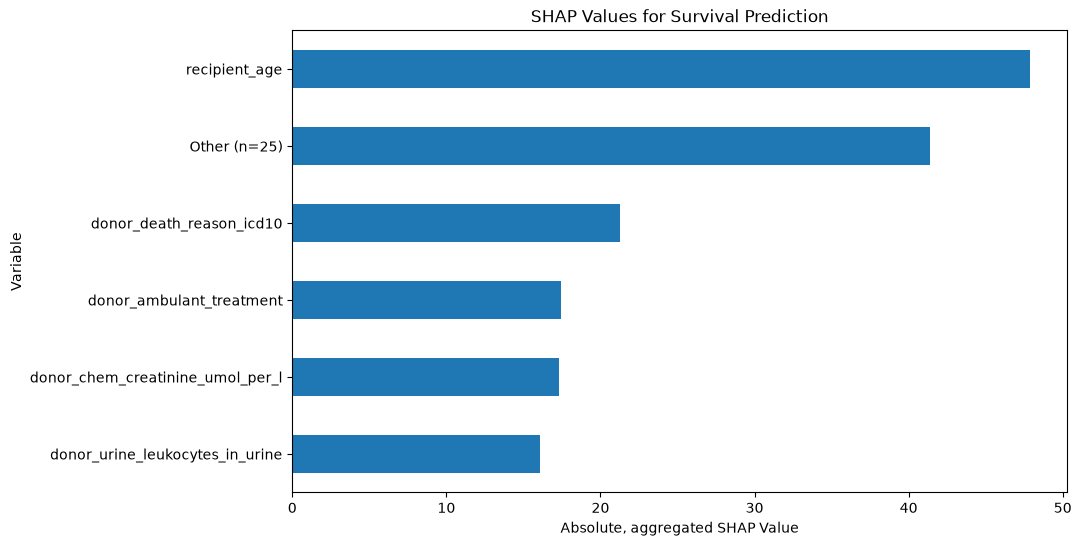

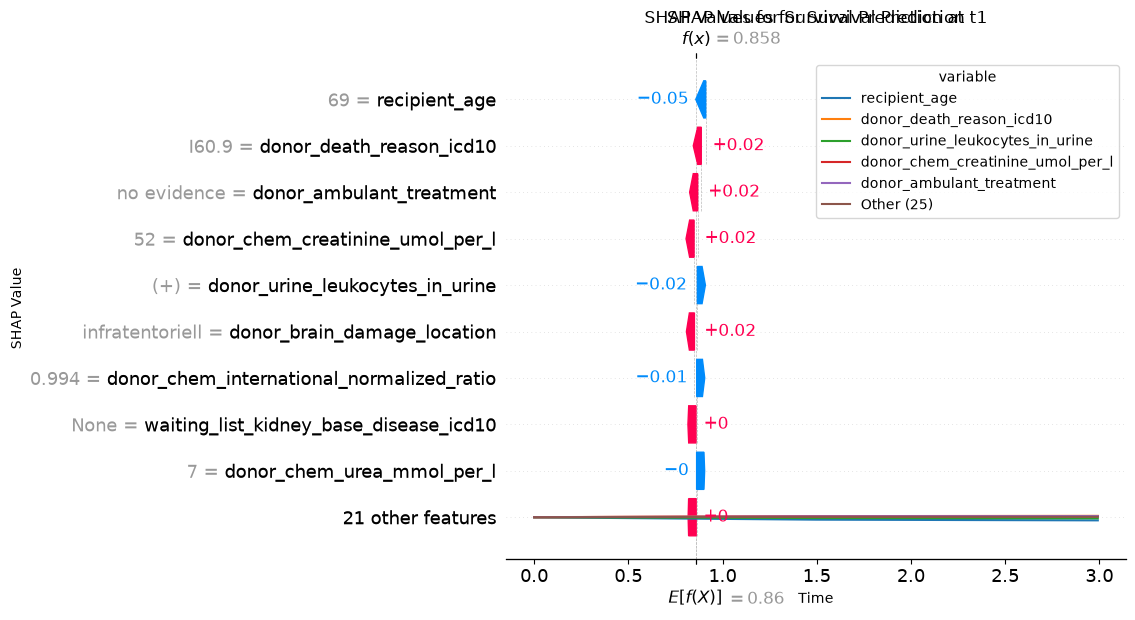

In [52]:
from shap.plots import waterfall
from shap import Explanation
import matplotlib.pyplot as plt

t_toshow ="t1"
tplt = shap_example_df.query("(observation == 0)").loc[:, ["variable", t_toshow]]
base_values = pd.Series(baseline, index=[f"t{i}" for i in range(len(timegrid))])

expl = Explanation(values=tplt.iloc[:,-1], base_values=base_values[t_toshow], feature_names=tplt["variable"].tolist(), data=pd.Series(ex)[tplt["variable"]])
waterfall(expl, max_display=10, show=False)
ax = plt.gca()
ax.set_title(f"SHAP Values for Survival Prediction at {t_toshow}")
plt.show()

More informationen on how to get the data for this plot

In [53]:
shap_dfs

[{'observation': 0,
  'variable': 'waiting_list_kidney_base_disease_icd10',
  'aggregated_change': 3.694820918000914,
  't0': 0.0001574852190958607,
  't1': 0.00408389002985017,
  't2': 0.005200023369506427},
 {'observation': 0,
  'variable': 'recipient_age',
  'aggregated_change': 47.90159564683071,
  't0': -0.0019771799126861852,
  't1': -0.05274399678763319,
  't2': -0.06788376011833426},
 {'observation': 0,
  'variable': 'transplantation_destination',
  'aggregated_change': 0.0,
  't0': 0.0,
  't1': 0.0,
  't2': 0.0},
 {'observation': 0,
  'variable': 'waiting_list_dialysis_years',
  'aggregated_change': 0.0,
  't0': 0.0,
  't1': 0.0,
  't2': 0.0},
 {'observation': 0,
  'variable': 'recipient_hepatitis_c_antibodies',
  'aggregated_change': 0.0,
  't0': 0.0,
  't1': 0.0,
  't2': 0.0},
 {'observation': 0,
  'variable': 'donor_brain_damage_location',
  'aggregated_change': 14.22979037435897,
  't0': 0.0006029693223466273,
  't1': 0.015718085748446534,
  't2': 0.02005053456404658},
 {'

## Using Callbacks

We need to define a small server receiving the callbacks.

This is just a example and very bad for production.

In [54]:
callback_port = 8889

import threading
from flask import Flask, request
from flask_cors import CORS

callback_event = threading.Event()

app = Flask(__name__)
CORS(app)

@app.route("/job/<job_id>", methods=["POST"])
def callback(job_id):
    print("Callback received:", job_id)
    
    callback_event.set()
    return "Callback received", 200

def run_flask():
    app.run(port=callback_port, host="0.0.0.0")


In [55]:
if 'flask_thread' not in locals():
    flask_thread = threading.Thread(target=run_flask)
    flask_thread.daemon = True
    flask_thread.start()

In [56]:
time.sleep(1) # Give Flask some time to start
callback_url = f"http://127.0.0.1:{callback_port}/"


requests.post(callback_url + "job/test",json={"message": "Hello from the callback!"})
callback_event.clear()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8889
 * Running on http://192.168.16.3:8889
Press CTRL+C to quit
127.0.0.1 - - [11/Aug/2026 09:40:03] "POST /job/test HTTP/1.1" 200 -


Callback received: test


The callback receiving server must be accessible by the worker container. In my case, this notebook is running on the docker host.

In [57]:
my_ip = "host.docker.internal" # special docker dns entry to access host from container

In [58]:
ex2 = ex.copy()
ex2["recipient_age"] = ex2["recipient_age"]-1

This waits for the results.

In [59]:
#callback_event.clear()
#pred_job = s.post(baseurl + "explain_survival_table", json=[ex2], params={'callback_url':f"http://{my_ip}:{callback_port}/"}).json()
#callback_event.wait()
## give the system time to save the results
#time.sleep(1)
#s.get(baseurl + "job/" + pred_job["job_id"] + "/result").json()